# DREAMS Nodal Hosting Capacity at Time
This demo notebook is designed to show to to perform nodal hosting 
capacity calculations using DREAMS at a specific time in the model.

As mentioned in the previous notebook, this nodal hosting capaicty value
is calculated based on a single snapshot in timme.
However, there may be situations in which other known times are of interst.
Such as minimum and maximum demand times.
To that end, this notebook shows how:



In [1]:
import dreams

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

# Loading Demo Feeder
The demo feeder is loaded and a voltage profile plot is made to ensure
the model loads correctly, and that there is some headroom for voltage
fulctuations.
A plotly version is created to allow the selection of a random bus to test
by simply overing over the graph.

In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')


In [3]:

fig = feeder.plot(kind='plotly')

# Identification of Bus to Test

A random bus was selected from the model by hovering over the above plot.
Any valid bus can replace `sel_bus` below.

In [4]:
sel_bus = 'p1udt16'
feeder.buses.loc[sel_bus]

longitude   -122.398544
latitude      37.757311
n_phases              3
phases              123
kv_base        7.199558
primary            True
distance       1.365715
Name: p1udt16, dtype: object

# Identify Time Indicies to Test
As mentioned, before, times of interest often include minimum and maximum
demand times.
Pandas is used to load the substation demand data and identify the minimum
and maximum index values - which are then transformed into time values.

<Axes: >

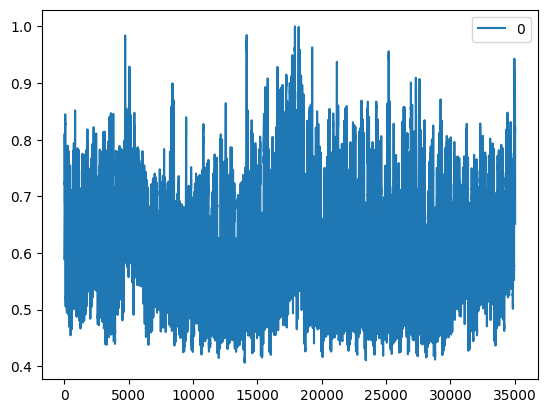

In [5]:
demand_fp = model_dir / 'pu_substation_demand.csv'
demand = pd.read_csv(demand_fp, header=None)
demand.plot()

In [6]:
# adding 1 to account for opendss first time step = 1
min_idx = demand[0].idxmin() + 1
max_idx = demand[0].idxmax() + 1

time_step_sec = 15 * 60 # 15 minute data

min_t = min_idx * time_step_sec
max_t = max_idx * time_step_sec


# Load (Demand) Hosting Capacity
First, a default call of the standard `NodalSnapshot` function is performed to 
get a baseline result.

As shown below, since `sel_bus` is a single string, it must be transformed
to a list to meet function input requirements.


In [7]:
voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=[sel_bus])
voltage_hc.result_df


Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.34 seconds)  


,voltage_hc_kw,iterations,over_voltage,under_voltage,line_overload,xfmr_overload,n_violation_types,bus_dist_km
p1udt16,15305,18,False,True,True,False,2,1.365715


To Two additional parameters are passed to the function to ensure that the 
specific profile is used, and the passed in time is selected.

In this case, all loads were calibrated such that their `duty` followed the
correct demand profile.

Since this profile is PU, the expectation is that this result should be 
very similar to the standard 'no time' solution.

In [8]:
vchc_max_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[sel_bus],
    mode='duty',
    at_sec=max_t,
    )
vchc_max_demand.result_df

Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.22 seconds)  


,voltage_hc_kw,iterations,over_voltage,under_voltage,line_overload,xfmr_overload,n_violation_types,bus_dist_km
p1udt16,15309,18,False,True,True,False,2,1.365715


The next solution, which is executed at the minimum demand time, is likely 
to present a much different hosing capacity result.

In [9]:
vchc_min_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[sel_bus],
    mode='duty',
    at_sec=min_t,
    )
vchc_min_demand.result_df

Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.28 seconds)  


,voltage_hc_kw,iterations,over_voltage,under_voltage,line_overload,xfmr_overload,n_violation_types,bus_dist_km
p1udt16,24547,18,False,True,True,False,2,1.365715


# Generation (PV) Hosting Capacity
The time of simulation also impacts the PV hosting capacity.
Below are results from minimum and maximum demand times.

In [10]:
pv_vchc_max_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[sel_bus],
    hc_kind='pv',
    mode='duty',
    at_sec=max_t,
    )
pv_vchc_max_demand.result_df


Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.17 seconds)  


,voltage_hc_kw,iterations,over_voltage,under_voltage,line_overload,xfmr_overload,n_violation_types,bus_dist_km
p1udt16,13414,17,True,False,True,False,2,1.365715


In [11]:
pv_vchc_min_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[sel_bus],
    hc_kind='pv',
    mode='duty',
    at_sec=min_t,
    )
pv_vchc_min_demand.result_df


Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.31 seconds)  


,voltage_hc_kw,iterations,over_voltage,under_voltage,line_overload,xfmr_overload,n_violation_types,bus_dist_km
p1udt16,10083,17,True,False,True,False,2,1.365715


# Results

The difference between minimum and maximum demand can have large impacts on 
hosting capacity results.

As shown, demand hosting capacity was 10 MW different between the two times
and PV hosting capacity reported a 3 MW difference.

